**Load the dataset**: Import the CVD_cleaned.csv file for analysis.

**Encode categorical data**: Convert text columns into numerical values.

**Separate features and target**: Split the dataset into X (features) and y (target variable: Heart_Disease).

**Split data**: Divide the dataset into training (80%) and testing (20%) sets.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from google.colab import files
uploaded =files.upload()

# Load the dataset
data = pd.read_csv('CVD_cleaned.csv')

# Encode categorical variables
label_encoders = {}
categorical_columns = data.select_dtypes(include=['object']).columns

for col in categorical_columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

# Separate features and target
X = data.drop(['Heart_Disease'], axis=1)
y = data['Heart_Disease']

# Split the dataset into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Saving CVD_cleaned.csv to CVD_cleaned.csv
Training set size: 247083
Test set size: 61771


**Load the dataset**: Import the CVD_cleaned.csv file for analysis.

**Encode categorical data**: Convert text columns into numerical values.

S**eparate features and target**: Split the dataset into X (features) and y (target variable: Heart_Disease).

**Split data**: Divide the dataset into training (80%) and testing (20%) sets.

**Train models**: Use Support Vector Machine, Random Forest, and Logistic Regression to train on the data.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import time

# Measure the start time
start_time = time.time()

# Load the dataset
data = pd.read_csv('CVD_cleaned.csv')
print("Dataset loaded successfully.")
print("First 5 rows of the dataset:\n", data.head())

# Encode categorical variables
label_encoders = {}
categorical_columns = data.select_dtypes(include=['object']).columns
print("Categorical columns to be encoded:", categorical_columns)

for col in categorical_columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

print("Categorical columns encoded successfully.")
print("First 5 rows of the encoded dataset:\n", data.head())

# Separate features and target
X = data.drop('Heart_Disease', axis=1)
y = data['Heart_Disease']

# Verify the shapes of X and y
print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verify the shapes of the train and test sets
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

# Initialize models with optimized parameters for quick training
svm_model = SVC(random_state=42, kernel='linear', max_iter=1000)
rf_model = RandomForestClassifier(random_state=42, n_estimators=10)
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the models
svm_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
lr_model.fit(X_train, y_train)

print("Models have been trained successfully.")

Dataset loaded successfully.
First 5 rows of the dataset:
   General_Health                  Checkup Exercise Heart_Disease Skin_Cancer  \
0           Poor  Within the past 2 years       No            No          No   
1      Very Good     Within the past year       No           Yes          No   
2      Very Good     Within the past year      Yes            No          No   
3           Poor     Within the past year      Yes           Yes          No   
4           Good     Within the past year       No            No          No   

  Other_Cancer Depression Diabetes Arthritis     Sex Age_Category  \
0           No         No       No       Yes  Female        70-74   
1           No         No      Yes        No  Female        70-74   
2           No         No      Yes        No  Female        60-64   
3           No         No      Yes        No    Male        75-79   
4           No         No       No        No    Male          80+   

   Height_(cm)  Weight_(kg)    BMI Smoking_Hi

/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Models have been trained successfully.


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**Test the models**: Use trained Support Vector Machine, Random Forest, and Logistic Regression models to predict outcomes on the testing dataset.

In [ ]:
# Test the models on unseen data
svm_predictions = svm_model.predict(X_test)
rf_predictions = rf_model.predict(X_test)
lr_predictions = lr_model.predict(X_test)

print('Models have been tested on the unseen data')

Models have been tested on the unseen data


**Evaluate models**: Measure the accuracy of SVM, Random Forest, and Logistic Regression models using accuracy_score.

**Generate reports**: Create classification reports and confusion matrices to analyze the models' performance.

**Output results**: Display accuracy, detailed performance reports, and confusion matrices for each model.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Evaluate the models
svm_accuracy = accuracy_score(y_test, svm_predictions)
rf_accuracy = accuracy_score(y_test, rf_predictions)
lr_accuracy = accuracy_score(y_test, lr_predictions)

svm_report = classification_report(y_test, svm_predictions)
rf_report = classification_report(y_test, rf_predictions)
lr_report = classification_report(y_test, lr_predictions)

svm_cm = confusion_matrix(y_test, svm_predictions)
rf_cm = confusion_matrix(y_test, rf_predictions)
lr_cm = confusion_matrix(y_test, lr_predictions)

print("SVM Accuracy:", svm_accuracy)
print("Random Forest Accuracy:", rf_accuracy)
print("Logistic Regression Accuracy:", lr_accuracy)

print("SVM Classification Report:\n", svm_report)
print("Random Forest Classification Report:\n", rf_report)
print("Logistic Regression Classification Report:\n", lr_report)

print("SVM Confusion Matrix:\n", svm_cm)
print("Random Forest Confusion Matrix:\n", rf_cm)
print("Logistic Regression Confusion Matrix:\n", lr_cm)


SVM Accuracy: 0.23222871574039597
Random Forest Accuracy: 0.9156076476016254
Logistic Regression Accuracy: 0.918942545854851
SVM Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.18      0.30     56774
           1       0.09      0.88      0.16      4997

    accuracy                           0.23     61771
   macro avg       0.51      0.53      0.23     61771
weighted avg       0.87      0.23      0.28     61771

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.99      0.96     56774
           1       0.35      0.05      0.09      4997

    accuracy                           0.92     61771
   macro avg       0.64      0.52      0.52     61771
weighted avg       0.88      0.92      0.89     61771

Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96     56774
  

**Visualize accuracies**: Create a bar plot to compare the accuracy of SVM, Random Forest, and Logistic Regression models.

**Display plot**: Generate a visualization to easily interpret model performance.

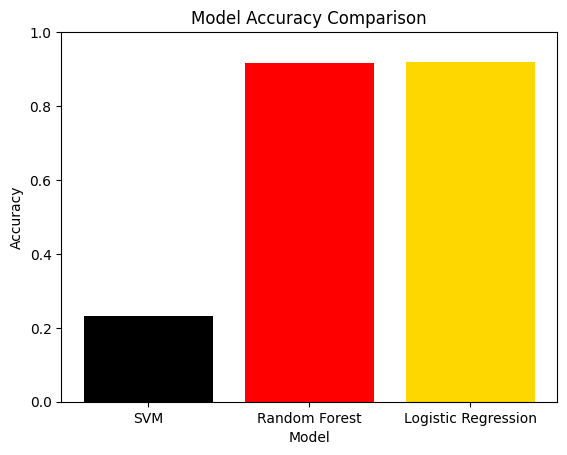

In [ ]:
import matplotlib.pyplot as plt

# Plot comparison of accuracies
accuracies = [svm_accuracy, rf_accuracy, lr_accuracy]
model_names = ['SVM','Random Forest','Logistic Regression']
plt.bar(model_names,accuracies,color = ['black','red','gold'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylim(0,1) # Ensures the y-axis ranges from 0 to 1
plt.show()

**Define parameter grid**: Specify hyperparameters for Random Forest tuning.

**Initialize Random Forest**: Set up the base model with a random state for consistency.

**Optimize parameters**: Use RandomizedSearchCV to find the best hyperparameter combination.

**Train the best model**: Fit the model using the optimal parameters on the training data.

**Evaluate performance**: Assess accuracy, classification report, and confusion matrix for the best model.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter grid for Random Forest
param_dist = {
    "n_estimators": [100, 200, 300],
    "max_features": ["auto", "sqrt"],
    "max_depth": [None, 10, 20],
    "criterion": ["gini", "entropy"]
}

# Initialize the Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Apply RandomizedSearchCV
rscv = RandomizedSearchCV(rf_model, param_distributions=param_dist, n_iter=10, cv=5, random_state=42, n_jobs=-1)
rscv.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters found: ", rscv.best_params_)
print("Best score from RandomizedSearchCV: ", rscv.best_score_)

# Evaluate the best model
best_rf_model = rscv.best_estimator_
best_rf_predictions = best_rf_model.predict(X_test)

best_rf_accuracy = accuracy_score(y_test, best_rf_predictions)
print("Best Random Forest Model Accuracy: ", best_rf_accuracy)
print("Best Random Forest Classification Report:\n", classification_report(y_test, best_rf_predictions))
print("Best Random Forest Confusion Matrix:\n", confusion_matrix(y_test, best_rf_predictions))


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
30 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/_

Best parameters found:  {'n_estimators': 300, 'max_features': 'sqrt', 'max_depth': 20, 'criterion': 'entropy'}
Best score from RandomizedSearchCV:  0.9192336161580241
Best Random Forest Model Accuracy:  0.9192339447313465
Best Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96     56774
           1       0.52      0.02      0.04      4997

    accuracy                           0.92     61771
   macro avg       0.72      0.51      0.50     61771
weighted avg       0.89      0.92      0.88     61771

Best Random Forest Confusion Matrix:
 [[56679    95]
 [ 4894   103]]


**Optimize Random Forest**: Hyperparameter tuning is performed using RandomizedSearchCV to improve model performance.

**Reduced hyperparameter space**: Limits the number of combinations for quicker execution.

**Train and evaluate best model**: Fit the optimal Random Forest model and assess its performance using accuracy metrics and reports.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# Load the dataset
file_path = "CVD_cleaned.csv"  # Update this path to your actual dataset file location
data = pd.read_csv(file_path)

# Encode categorical variables
label_encoders = {}
for column in data.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    data[column] = le.fit_transform(data[column])
    label_encoders[column] = le

# Separate features and target
X = data.drop(columns=["Heart_Disease"])
y = data["Heart_Disease"]

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the model
model = RandomForestClassifier(random_state=42)

# Reduce the number of iterations and limit hyperparameter space for quicker execution
param_distributions_reduced = {
    "n_estimators": [int(x) for x in range(100, 501, 100)],  # Reduced range
    "max_depth": [10, 20, 30, None],  # Reduced choices
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "criterion": ["gini", "entropy"]
}
# Set up RandomizedSearchCV with fewer iterations
random_search_reduced = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_distributions_reduced,
    n_iter=20,  # Reduced iterations
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit RandomizedSearchCV
random_search_reduced.fit(X_train, y_train)

# Get the best parameters and best score
best_params_reduced = random_search_reduced.best_params_
best_score_reduced = random_search_reduced.best_score_

print("Best Parameters:", best_params_reduced)
print("Best Score:", best_score_reduced)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameters: {'n_estimators': 400, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 20, 'criterion': 'entropy'}
Best Score: 0.9192659956370935
